# W1 – Project Scope
## Topic 5: Continual Learning against Catastrophic Forgetting in Dermatology
**Course:** Advanced Machine Learning 2025/2026  
**Deadline:** 10/05/2026


## 1. Problem Statement
Continual learning (CL) addresses the challenge of learning from a **non-stationary data stream** where new tasks arrive sequentially. Standard deep networks suffer from **catastrophic forgetting**: performance on old tasks degrades drastically when learning new ones.

In the medical domain, this is critical: a model deployed in a dermatology clinic must:
- Learn new skin disease types as they emerge
- Retain high accuracy on previously learned conditions
- Work within memory and compute constraints (no full retraining)


## 2. Dataset: DermaMNIST
- Part of [MedMNIST](https://medmnist.com/) benchmark
- **28×28 RGB** dermoscopic images
- **7 classes**: Melanocytic nevi, Melanoma, Benign keratosis, Basal cell carcinoma, Actinic keratoses, Vascular lesions, Dermatofibroma
- **Train/Val/Test split**: 7007 / 1003 / 2005 images


## 3. Task Split (Class-Incremental)
| Task | Classes | Description |
|------|---------|-------------|
| Task 0 | 0,1,2 | Nevi, Melanoma, Keratosis |
| Task 1 | 3,4 | BCC, Actinic Keratoses |
| Task 2 | 5,6 | Vascular, Dermatofibroma |

Each task is presented sequentially. No future task data is available during training.


## 4. Methods
| Method | Type | Description |
|--------|------|-------------|
| Naive Fine-tuning | Baseline | SGD on new task only — shows forgetting |
| EWC | Regularization | Penalizes changes to important weights |
| LwF | Regularization | Knowledge distillation from old model |
| Experience Replay | Memory-based | Replay stored past examples |
| Joint Training | Oracle | All data at once — upper bound |


## 5. Metrics
- **FAA (Final Average Accuracy)**: $\frac{1}{T}\sum_{t=1}^{T} R_{T,t}$
- **BWT (Backward Transfer)**: $\frac{1}{T-1}\sum_{t=1}^{T-1}(R_{T,t} - R_{t,t})$ — negative = forgetting


In [1]:
# Install dependencies
# !pip install medmnist torch torchvision matplotlib seaborn scikit-learn tqdm pandas

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
print(f'PyTorch: {torch.__version__}')
try:
    import medmnist
    print(f'MedMNIST: {medmnist.__version__}')
except ImportError:
    print('Install medmnist: pip install medmnist')


PyTorch: 2.10.0+cpu
MedMNIST: 3.0.2


Train size: 7007
Classes: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}


C:\Users\LENOVO T14S\AppData\Local\Temp\ipykernel_31480\190219310.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lbl = int(label)
C:\Users\LENOVO T14S\AppData\Local\Temp\ipykernel_31480\190219310.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_all = [int(ds[i][1]) for i in range(len(ds))]
C:\Users\LENOVO T14S\AppData\Local\Temp\ipykernel_31480\190219310.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(class_names, rotation=30, ha='right', fontsize=8)


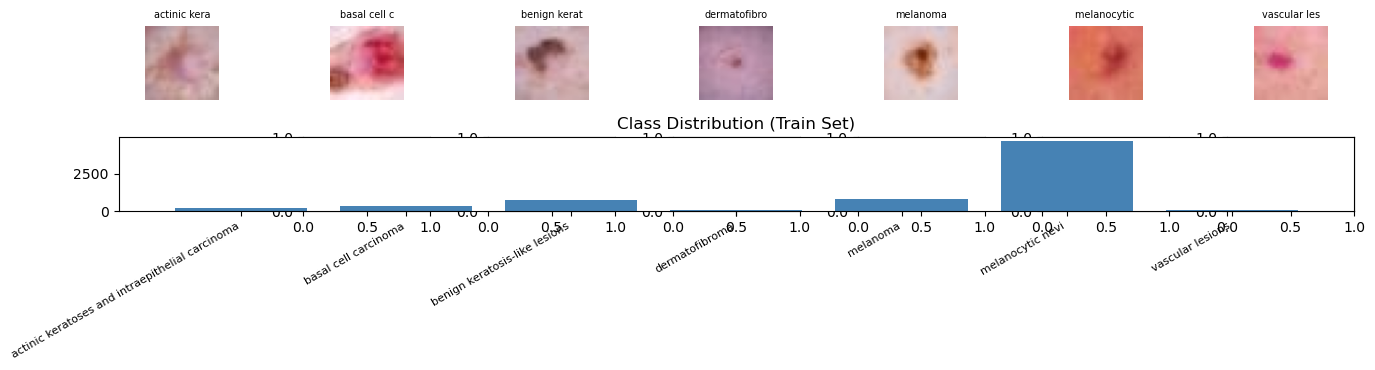

Saved: results/w1_dataset_preview.png


In [2]:
# Quick dataset preview
try:
    from medmnist import DermaMNIST
    from torchvision import transforms
    import matplotlib.pyplot as plt
    import numpy as np

    transform = transforms.Compose([transforms.ToTensor()])
    ds = DermaMNIST(split='train', transform=transform, download=True, root='../data')
    print(f'Train size: {len(ds)}')
    print(f'Classes: {ds.info["label"]}')

    # Show sample images
    fig, axes = plt.subplots(2, 7, figsize=(14, 4))
    class_names = list(ds.info['label'].values())
    shown = {i: False for i in range(7)}
    for img, label in ds:
        lbl = int(label)
        if not shown[lbl]:
            axes[0, lbl].imshow(img.permute(1,2,0).numpy())
            axes[0, lbl].set_title(class_names[lbl][:12], fontsize=7)
            axes[0, lbl].axis('off')
            shown[lbl] = True
        if all(shown.values()): break
    # Label distribution
    labels_all = [int(ds[i][1]) for i in range(len(ds))]
    counts = np.bincount(labels_all)
    axes[1, 0].remove()
    ax2 = fig.add_subplot(2, 1, 2)
    ax2.bar(class_names, counts, color='steelblue')
    ax2.set_xticklabels(class_names, rotation=30, ha='right', fontsize=8)
    ax2.set_title('Class Distribution (Train Set)')
    plt.tight_layout()
    plt.savefig('../results/w1_dataset_preview.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: results/w1_dataset_preview.png')
except Exception as e:
    print(f'Error: {e}. Run: pip install medmnist')


## 6. Git & Repository Setup
```bash
git init
git add .
git commit -m 'W1: project scope, repo structure, dataset preview'
```


## 7. References
1. Kirkpatrick et al. (2017). *Overcoming catastrophic forgetting in neural networks*. PNAS.
2. Li & Hoiem (2017). *Learning without Forgetting*. TPAMI.
3. Yang et al. (2023). *MedMNIST v2 — A large-scale lightweight benchmark for 2D and 3D biomedical image classification*. Sci. Data.
4. Thandiackal et al. (2021). *LifeLonger: A Benchmark for Continual Disease Classification*.
